# Explanation: This file is used for network score calculation, including comprehensive scores

In [1]:
import pandas as pd
import networkx as nx
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
import matplotlib.pyplot as plt
import os
import igraph as ig
import numpy as np

In [ ]:
# File path settings
base_path = r'..\code\\'
node_path = base_path + 'patent_node.csv'
edge_path = base_path + 'patent_edge.csv'
score_path = base_path + '02patents_normalized_with_scores.csv'

In [3]:
def get_largest_cc(G):
    """Get the largest weakly connected component"""
    if nx.is_weakly_connected(G):
        print("The network is connected")
        return G
    print("The network is not connected, extracting the giant connected component...")
    largest_cc = max(nx.weakly_connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

In [4]:
def personalized_hits(G, personalization, alpha=0.5, max_iter=1000):
    """HITS algorithm with personalized initial values and hybrid damping model"""
    # Initialize Hub and Authority to personalized values
    hub = personalization.copy()
    authority = personalization.copy()
    
    # Get all nodes in the graph
    nodes = list(G.nodes())
    
    for _ in range(max_iter):
        # ------ Authority Update ------
        # Calculate raw Authority scores (without damping)
        raw_authority = {}
        for n in nodes:
            raw_authority[n] = sum(hub[p] for p in G.predecessors(n))
        
        # Apply damping factor and personalized values
        authority = {
            n: alpha * raw_authority[n] + (1 - alpha) * personalization[n]
            for n in nodes
        }
        
        # Normalize Authority scores
        auth_sum = sum(authority.values()) or 1  # Prevent division by 0
        authority = {n: val/auth_sum for n, val in authority.items()}
        
        # ------ Hub Update ------
        # Calculate raw Hub scores (without damping)
        raw_hub = {}
        for n in nodes:
            raw_hub[n] = sum(authority[s] for s in G.successors(n))
        
        # Apply damping factor and personalized values
        hub_new = {
            n: alpha * raw_hub[n] + (1 - alpha) * personalization[n]
            for n in nodes
        }
        
        # Normalize Hub scores
        hub_sum = sum(hub_new.values()) or 1  # Prevent division by 0
        hub = {n: val/hub_sum for n, val in hub_new.items()}
    
    return authority, hub

In [ ]:
def main():
    try:
        # Data loading
        nodes = pd.read_csv(node_path)
        edges = pd.read_csv(edge_path)
        scores = pd.read_csv(score_path)[['patent_id', 'P_score']]

        # Build original network
        G = nx.DiGraph()
        G.add_nodes_from(nodes['patent_id'])
        G.add_edges_from(zip(edges['from'], edges['to']))

        # Get giant connected component
        G_lcc = get_largest_cc(G)
        lcc_nodes = set(G_lcc.nodes())

        # Calculate original scores
        pr_raw = nx.pagerank(G_lcc, alpha=0.5)
        hits_raw = nx.hits(G_lcc, max_iter=1000)
        au_raw, hub_raw = hits_raw[1], hits_raw[0]

        # Process personalized scores
        node_data = nodes.merge(scores, on='patent_id', how='left')
        node_data['P'] = node_data['P_score'].fillna(0)
        
        # Personalized scores normalization (probability distribution)
        scaler = MinMaxScaler()
        node_data['norm_score'] = scaler.fit_transform(node_data[['P']])
        sum_score = node_data['norm_score'].sum()
        personalization = dict(zip(node_data['patent_id'], 
                                node_data['norm_score']/sum_score))

        # Personalized PageRank
        pr_personal = nx.pagerank(
            G_lcc,
            alpha=0.5,
            personalization={k:v for k,v in personalization.items() if k in lcc_nodes},
            max_iter=1000
        )

        # Personalized HITS
        au_personal, hub_personal = personalized_hits(
            G_lcc,
            personalization={k:v for k,v in personalization.items() if k in lcc_nodes}
        )

        # Result integration
        results = []
        for patent in nodes['patent_id']:
            in_lcc = patent in lcc_nodes
            results.append({
                'patent_id': patent,
                'pr': pr_raw.get(patent, 0) if in_lcc else 0,
                'au': au_raw.get(patent, 0) if in_lcc else 0,
                'hub': hub_raw.get(patent, 0) if in_lcc else 0,
                'PR': pr_personal.get(patent, 0) if in_lcc else 0,
                'AU': au_personal.get(patent, 0) if in_lcc else 0,
                'HUB': hub_personal.get(patent, 0) if in_lcc else 0,
                'in_lcc': in_lcc
            })
        
        # Merge attribute scores
        final_df = pd.DataFrame(results).merge(
            node_data[['patent_id', 'P']], 
            on='patent_id', 
            how='left'
        )

        # Adjust column order
        final_df = final_df[['patent_id', 'in_lcc','P', 'pr', 'au', 'hub',
                            'PR', 'AU', 'HUB']]
        
        # Save results
        output_path = base_path + 'network_analysis_full_results.csv'
        final_df.to_csv(output_path, index=False)

        
        print(f"Calculation completed! Results saved to: {output_path}")
        print("\nResult field description:")
        print(final_df.dtypes)
        print("\nStatistical information:")
        print(f"Giant connected component contains {len(lcc_nodes)} nodes (proportion {len(lcc_nodes)/len(G):.1%})")
        print(final_df.describe())

    except Exception as e:
        print(f"Execution error: {str(e)}")

if __name__ == "__main__":
    main()

In [ ]:
# Data loading
nodes = pd.read_csv(node_path)
edges = pd.read_csv(edge_path)
scores = pd.read_csv(score_path)[['patent_id', 'P_score']]

# Build original network
G = nx.DiGraph()
G.add_nodes_from(nodes['patent_id'])
G.add_edges_from(zip(edges['from'], edges['to']))

# Get giant connected component
G_lcc = get_largest_cc(G)
lcc_nodes = set(G_lcc.nodes())

网络非连通，提取巨连通分支...


In [ ]:
def probability_matrix(G):
    """Convert adjacency matrix to probability transition matrix"""
    n = G.shape[0]
    cs = G.sum(axis=0)
    cs[cs == 0] = 1  # Handle all-zero columns
    A = G / cs
    
    # Check and handle all-zero columns that still exist after conversion
    column_sums = A.sum(axis=0)
    for j in range(n):
        if column_sums[j] == 0:
            A[:, j] = 1.0 / n
    return A

def eigen_matrix(G1, G2, alpha=0.5,iter_max=100, p=0.15, epsilon=1e-5):
    """Improved HITS algorithm implementation"""
    n = G1.shape[0]
    x = np.ones(n)
    y = np.ones(n)
    
    # If p is scalar, convert to vector
    if isinstance(p, (int, float)):
        p = np.full(n, p)
    
    for num_iter in range(iter_max):
        x_prev = x.copy()
        x = alpha * G1 @ y + (1-alpha)*p
        y = alpha * G2 @ x + (1-alpha)*p
        
        if np.sum(np.abs(x - x_prev)) < epsilon:
            break
    
    # Normalize results
    auth = x / x.sum()
    hub = y / y.sum()
    return auth, hub, num_iter + 1

# ========== New section: Read and process P_score ==========
base_path = r'..\code\\'
score_path = base_path + '02patents_normalized_with_scores.csv'

# Read P_score data
p_scores = pd.read_csv(score_path)
p_score_dict = pd.Series(p_scores.P_score.values, index=p_scores.patent_id).to_dict()

# ========== Main program ==========
# Assume graph is the created NetworkX directed graph
sorted_nodes = sorted(G_lcc.nodes())

# Verify node and P_score matching
missing_nodes = [node for node in sorted_nodes if node not in p_score_dict]
if missing_nodes:
    raise ValueError(f"The following nodes are missing P_score values: {missing_nodes[:5]}... (total {len(missing_nodes)})")

# Generate P vector (ensure order matches adjacency matrix)
p_vector = np.array([p_score_dict[node] for node in sorted_nodes])

# Generate adjacency matrix
adj_mat = nx.to_numpy_array(G_lcc, nodelist=sorted_nodes)
A = adj_mat.T  # Transpose matrix

# Generate probability transition matrix
G1 = probability_matrix(A)
G2 = probability_matrix(A.T)  # Note that the transpose matrix is used here

# Run algorithm (using real P_score values)
auth, hub, iterations = eigen_matrix(G1, G2, alpha=0.5,iter_max=200, p=p_vector)

# Build result DataFrame
hits_result = pd.DataFrame({
    'patent_id':sorted_nodes,
    'AU': auth,
    'HUB': hub,
    'iterations': iterations
}, index=sorted_nodes)

# Output results
print("HITS results:")
print(hits_result.head())

HITS 结果:
         patent_id        AU       HUB  迭代次数
4533934    4533934  0.000092  0.000086    16
4996574    4996574  0.001458  0.000081    16
5115289    5115289  0.000273  0.000088    16
5120666    5120666  0.000170  0.000064    16
5281547    5281547  0.000126  0.000099    16


In [ ]:
final_df = pd.read_csv(r'network_analysis_full_results.csv')

# Step 1: Set index for alignment
final_df = final_df.set_index('patent_id')
hits_to_merge = hits_result.set_index('patent_id')[['AU', 'HUB']]

# Step 2: Perform column update
final_df.update(hits_to_merge)

# Step 3: Reset index to restore column structure
final_df = final_df.reset_index()

# Verify results
print("Updated column statistics:")
print(final_df[['AU', 'HUB']].describe())

print("\nSample data (first 5 rows):")
print(final_df.head())
final_df.to_csv(r'network_analysis_full_results.csv', index=False)

更新后的列统计：
                 AU           HUB
count  1.009700e+04  10097.000000
mean   9.903932e-05      0.000099
std    2.051300e-04      0.000081
min   -6.917914e-07      0.000000
25%    0.000000e+00      0.000000
50%    7.665933e-05      0.000104
75%    1.080268e-04      0.000142
max    8.135993e-03      0.001230

示例数据（前5行）：
   patent_id  in_lcc         P        pr        au       hub        PR  \
0    4533934    True  0.392044  0.000097  0.000002 -0.000000  0.000092   
1    5115289    True  0.402713  0.000390  0.000314 -0.000000  0.000380   
2    5309010    True  0.217778  0.000096  0.000010  0.000124  0.000069   
3    5120666    True  0.262932  0.000150  0.006920 -0.000000  0.000133   
4    5409850   False  0.334641  0.000000  0.000000  0.000000  0.000000   

         AU       HUB  
0  0.000092  0.000086  
1  0.000273  0.000088  
2  0.000056  0.000117  
3  0.000170  0.000064  
4  0.000000  0.000000  


In [ ]:
base_path = r'..\code\\'

def filter_lcc_data():
    try:
        # Read complete results
        input_file = base_path + 'network_analysis_full_results.csv'
        full_df = pd.read_csv(input_file)
        
        # Filter giant connected component
        lcc_df = full_df[full_df['in_lcc']].copy()
        
        # Delete identifier column
        lcc_df.drop(columns=['in_lcc'], inplace=True)
        
        # Save results
        output_file = base_path + 'patent_lcc_dataset.csv'
        lcc_df.to_csv(output_file, index=False)
        
        # Output verification
        print(f"Giant connected component dataset saved to: {output_file}")
        print(f"Number of patents included: {len(lcc_df):,}")
        print(f"File size: {lcc_df.memory_usage().sum()/1024/1024:.1f} MB")
        print("Field structure:")
        print(lcc_df.dtypes.to_string())
        
        return lcc_df
    
    except Exception as e:
        print(f"Processing failed: {str(e)}")
        print("Please check:")
        print(f"1. Does the input file exist: {input_file}")
        print("2. Does the original file contain the 'in_lcc' field")
        return None

# Execute processing
if __name__ == "__main__":
    lcc_data = filter_lcc_data()
    if lcc_data is not None:
        print("\nData sample:")
        print(lcc_data.sample(3, random_state=42))

In [ ]:
# ================== Export node data ==================
# Extract node attribute data
node_data = G_lcc.nodes(data=True)

# Convert to DataFrame
nodes_df = pd.DataFrame({'node_id': list(G_lcc.nodes)})

# Save node data
nodes_df.to_csv('sub_node.csv', index=False)

# ================== Export edge data ==================
# Use NetworkX built-in function to convert edge list
edges_df = nx.to_pandas_edgelist(G_lcc)

# Rename columns (optional)
if 'weight' in edges_df.columns:
    edges_df = edges_df.rename(columns={'weight': 'edge_weight'})

# Save edge data
edges_df.to_csv('sub_edge.csv', index=False)

# ================== Verify output ==================
print(f"Node file dimensions: {nodes_df.shape}")
print(f"Edge file dimensions: {edges_df.shape}")
print("Export completed! First 3 rows of nodes example:")
print(nodes_df.head(3))
print("\nFirst 3 rows of edges example:")
print(edges_df.head(3))

节点文件维度：(7412, 1)
边文件维度：(32633, 2)
导出完成！前3行节点示例：
   node_id
0  4533934
1  5115289
2  5309010

前3行边示例：
    source   target
0  5309010  4533934
1  5309010  4996574
2  5309010  5115289


In [ ]:
def calculate_network_properties(G):
    """
    Calculate basic topological features of the network graph
    
    Parameters:
    G (nx.Graph/nx.DiGraph): NetworkX graph object (supports directed/undirected)
    
    Returns:
    dict: Dictionary containing network properties (also prints results)
    """
    metrics = {
        "Number of nodes": G.number_of_nodes(),
        "Number of edges": G.number_of_edges(),
        "Network density": nx.density(G),
        "Number of connected components": None,
        "Proportion of nodes in largest connected subgraph": None,
        "Number of isolated nodes": len(list(nx.isolates(G)))
    }

    # Handle boundary case of empty graph
    if metrics["Number of nodes"] == 0:
        print("Warning: Empty graph!")
        return metrics

    # Calculate connected component related metrics
    try:
        if isinstance(G, nx.DiGraph):
            # Directed graph uses weakly connected components
            components = list(nx.weakly_connected_components(G))
            metrics["Number of connected components"] = len(components)
        else:
            # Undirected graph uses ordinary connected components
            components = list(nx.connected_components(G))
            metrics["Number of connected components"] = len(components)

        # Calculate proportion of largest connected subgraph
        if components:
            largest_component = max(components, key=len)
            metrics["Proportion of nodes in largest connected subgraph"] = len(largest_component) / metrics["Number of nodes"]
            
    except Exception as e:
        print(f"Connectivity calculation exception: {str(e)}")

    # Print results
    print("\nBasic network features:")
    for k, v in metrics.items():
        if isinstance(v, float):
            print(f"- {k}: {v:.4f}" if k == "Network density" else f"- {k}: {v:.1%}")
        else:
            print(f"- {k}: {v}")
    
    return metrics

# Usage example --------------------------------------------------
if __name__ == "__main__":
    # Example: Directed graph
    print("\n【Directed graph example】")
    G_directed = G
    directed_metrics = calculate_network_properties(G_directed)
    # Example: Giant component of directed graph
    print("\n【Directed graph example】")
    G_directed = G_lcc
    directed_metrics = calculate_network_properties(G_directed)


【有向图示例】

网络基本特征:
- 节点数: 10097
- 连边数: 33062
- 网络密度: 0.0003
- 连通分量数: 2366
- 最大连通子图节点占比: 73.4%
- 孤立节点数: 2185

【有向图示例】

网络基本特征:
- 节点数: 7412
- 连边数: 32633
- 网络密度: 0.0006
- 连通分量数: 1
- 最大连通子图节点占比: 100.0%
- 孤立节点数: 0


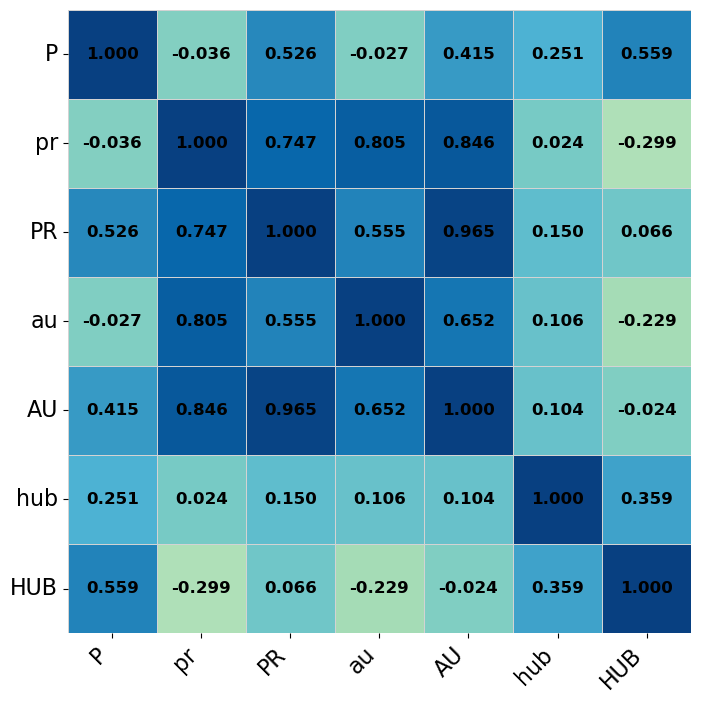

In [ ]:
# Set global font and style
plt.rcParams.update({'font.size': 14})
# plt.style.use('seaborn-talk')  # Use preset style with larger font size

# Create more compact figure (suitable for two-column papers)
fig = plt.figure(figsize=(10, 8))  # Adjust to size more suitable for papers

# Draw heatmap
heatmap = sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".3f",  # Keep two decimal places (more compact)
    cmap='GnBu',
    center=0,
    square=True,
    linewidths=0.5,
    linecolor='lightgray',
    cbar= False,
    # cbar_kws={
    #     "shrink": 0.8,
    #     "label": "Correlation",
    #     "labelsize": 14  # Colorbar font
    # },
    annot_kws={
        "size": 12,  # Correlation coefficient font
        "weight": "bold",  # Bold display
        "color": "black"
    },)
    # mask=np.triu(np.ones_like(spearman_corr, dtype=bool))  # Hide upper triangle

# Axis optimization
plt.xticks(
    rotation=45,  # Tilt 45 degrees
    ha='right',  # Alignment
    fontsize=16,  # X-axis label font
    fontweight='medium'
)
plt.yticks(
    rotation=0,
    fontsize=16,  # Y-axis label font
    fontweight='medium'
)

# Add label enhancements
# plt.xlabel("Features", fontsize=16, labelpad=15)
# plt.ylabel("Features", fontsize=16, labelpad=15)

# Compact layout
fig.tight_layout(pad=3)  # Increase margins

# Save settings
plt.savefig("spearman_heatmap.svg",  # Recommended to use PDF format
           bbox_inches='tight',
           dpi=300,
           transparent=True)  # Transparent background for easy layout
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load dataset (assuming processed and saved as patents.csv)
patents = pd.read_csv("patent_lcc_dataset.csv")

# Extract non-numeric columns (such as patent ID) and numeric columns
non_numeric_cols = ['patent_id']  # Non-numeric columns (keep identifiers)
numeric_cols = patents.columns.difference(non_numeric_cols).tolist()  # Numeric columns

# Separate data
numeric_data = patents[numeric_cols]
id_data = patents[non_numeric_cols]

# --- Normalization (Min-Max) ---
scaler_minmax = MinMaxScaler()
normalized_data = scaler_minmax.fit_transform(numeric_data)
df_normalized = pd.DataFrame(normalized_data, columns=numeric_cols)
df_normalized = pd.concat([id_data, df_normalized], axis=1)  # Merge ID column

# Save normalization results
new_order = ['patent_id','P','pr','au','hub','PR','AU','HUB',]
df_normalized = df_normalized[new_order]
df_normalized.to_csv("patent_score.csv", index=False)

print("Normalization results saved!")

归一化结果已保存！
